# TFM – Marketing Fintech Campaign Analysis

<a id="indice"></a>
## Índice

- [Introducción](#introduccion)
- [Imports](#imports)
- [Carga de datos](#carga-datos)
- [Exploración de datos inicial](#exploracion)
- [Visualización de los datos](#visualizacion)
- [Análisis de los datos](#analisis)
- [KPIs](#kpis)
- [Conclusiones](#conclusiones)


<a id="introduccion"></a>
## Introducción 📑

Este Notebook forma parte del **Trabajo Final de Máster (TFM)** enfocado al análisis de datos en el ámbito del marketing financiero.

El objetivo del proyecto es **analizar la información procedente de campañas de marketing telefónicas realizadas por una entidad bancaria**, con el fin de comprender qué factores influyen en la decisión de los clientes de contratar un depósito a plazo fijo.

A partir del análisis del dataset se busca identificar **patrones de comportamiento, variables relevantes y segmentos de clientes** que presenten mayor probabilidad de conversión.

En este documento se desarrollan las primeras fases del proyecto:

1. **Carga y revisión inicial del dataset**  
   - Importación del conjunto de datos y comprobación de su estructura.  
   - Análisis general del número de variables, tipos de datos y consistencia de la información.  
   - Primera inspección del contenido del dataset.

2. **Preparación y exploración inicial de los datos**  
   - Identificación de posibles valores problemáticos (categorías desconocidas, valores atípicos o inconsistencias).  
   - Evaluación de la calidad del dataset.  
   - Creación o transformación de variables que permitan enriquecer el análisis posterior.

3. **Análisis exploratorio de datos (EDA)**  
   - Estudio de variables demográficas como edad, profesión, nivel educativo o estado civil.  
   - Análisis de variables relacionadas con la campaña de marketing, como el tipo de contacto, el número de interacciones o la duración de las llamadas.  
   - Evaluación de la respuesta de los clientes ante la campaña (`y`).

4. **Análisis de relaciones entre variables**  
   - Comparación de diferentes segmentos de clientes según su comportamiento frente a la campaña.  
   - Identificación de patrones y posibles factores asociados a una mayor probabilidad de conversión.

5. **Modelo predictivo de conversión**  
   - Desarrollo de un modelo de predicción cuyo objetivo es estimar la probabilidad de que un cliente acepte la oferta del depósito a plazo fijo (`y = yes`).  
   - Evaluación del rendimiento del modelo y análisis de las variables con mayor capacidad predictiva.

El propósito de este análisis es **comprender mejor los factores que influyen en la efectividad de las campañas de marketing**, así como proporcionar información útil para mejorar la segmentación de clientes y optimizar futuras estrategias comerciales.

[⬆ Volver al índice](#indice)

<a id="imports"></a>
## Imports 📦

In [27]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from functions import *
from matplotlib import rcParams

# Expresiones regulares
import re
from fuzzywuzzy import process

[⬆ Volver al índice](#indice)

<a id="carga-datos"></a>
## Carga de datos 📂

In [28]:
df = pd.read_csv('../Data/bank-additional_bank-additional-full.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="exploracion"></a>
## Exploración de datos inicial 🔎

In [29]:
check_df(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
40072,37,admin.,married,high.school,no,yes,no,cellular,jul,thu,...,2,999,0,nonexistent,-1.7,94.215,-40.3,0.810,4991.6,no
11516,36,admin.,married,university.degree,no,yes,yes,telephone,jun,fri,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
669,54,admin.,married,high.school,no,no,no,telephone,may,tue,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
18908,57,admin.,married,high.school,unknown,yes,no,cellular,aug,mon,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
15008,41,technician,married,professional.course,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no



##########################################################################################

¿Cuál es el tipo de datos de cada columna?


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


##########################################################################################

¿Cuántas columnas hay de cada tipo de datos?


object     11
int64       5
float64     5
Name: count, dtype: int64


##########################################################################################

Variables numéricas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

##########################################################################################

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

##########################################################################################

¿Cuántos valores únicos tiene cada columna?


age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64


##########################################################################################

Estadísticas descriptivas (numéricas):


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



##########################################################################################

Estadísticas descriptivas (categóricas):


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



##########################################################################################



(       age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0       56       261         1    999         0           1.1          93.994   
 1       57       149         1    999         0           1.1          93.994   
 2       37       226         1    999         0           1.1          93.994   
 3       40       151         1    999         0           1.1          93.994   
 4       56       307         1    999         0           1.1          93.994   
 ...    ...       ...       ...    ...       ...           ...             ...   
 41183   73       334         1    999         0          -1.1          94.767   
 41184   46       383         1    999         0          -1.1          94.767   
 41185   56       189         2    999         0          -1.1          94.767   
 41186   44       442         1    999         0          -1.1          94.767   
 41187   74       239         3    999         1          -1.1          94.767   
 
        cons.c

In [30]:
identificacion_valores_problem(df)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
age               0.0
campaign          0.0
nr.employed       0.0
euribor3m         0.0
cons.conf.idx     0.0
cons.price.idx    0.0
emp.var.rate      0.0
poutcome          0.0
previous          0.0
pdays             0.0
duration          0.0
job               0.0
day_of_week       0.0
month             0.0
contact           0.0
loan              0.0
housing           0.0
default           0.0
education         0.0
marital           0.0
y                 0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 12
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "age": 469
Número de outliers en la columna "duration": 2963
Número de outliers e

In [31]:
print('la información duplicada que tenemos:')
df[df.duplicated()]

la información duplicada que tenemos:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [32]:
df.drop_duplicates(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="visualizacion"></a>
## Visualización de los datos 📊

In [33]:
df[['pdays','previous']].value_counts()

pdays  previous
999    0           35563
       1            3696
       2             349
3      1             250
6      1             220
                   ...  
13     3               1
11     4               1
2      5               1
12     4               1
999    6               1
Name: count, Length: 96, dtype: int64

Parece que el valor 999 tambíen está utilizado por personas que ya han sido contactados.

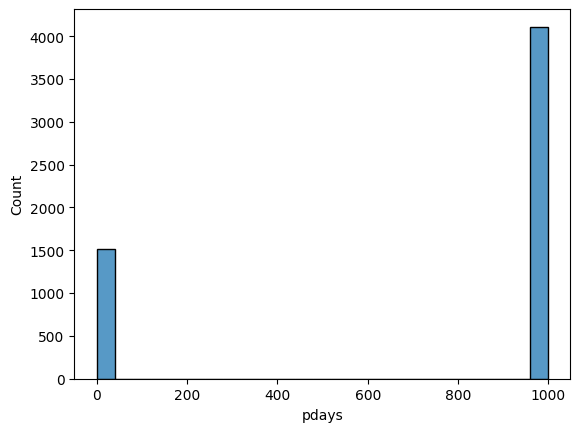

In [34]:
fig = sns.histplot(
    data=df.query('previous > 0'), 
    x="pdays",
    bins= 25
    )

Es el valor más utilizado. Hay que clarificar que significa el 999, si tambíen significa que ha sido mucho tiempo desde el último contacto.

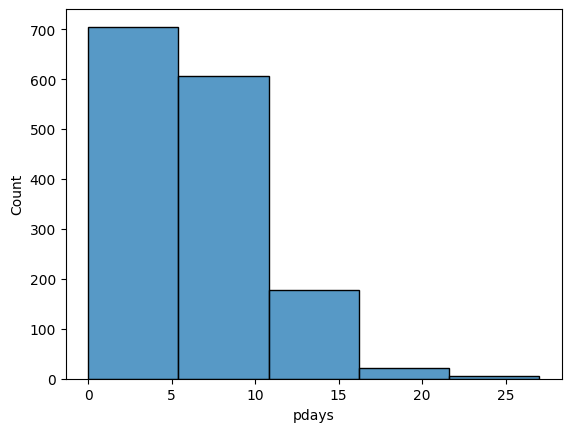

In [35]:
fig = sns.histplot(
    data=df.query('previous > 0 & pdays != 999'), 
    x="pdays",
    bins= 5
    )

Hay gente que han contactado bastante, pero la gran mayoría tienen menos de 10-11 intentos.

In [36]:
df.query('pdays != 999')['pdays'].describe().round(2)

count    1515.00
mean        6.01
std         3.82
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64

El máximo de días de contacto es 27 días, exceptuando los 999.

In [37]:
print(df['age'].value_counts())
print('-'*50)
print(df.age.unique())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
--------------------------------------------------
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]


Las personas más contactadas tienen una edad de 31 a 35 años.

In [38]:
df['campaign'].value_counts()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
28        8
26        8
25        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64

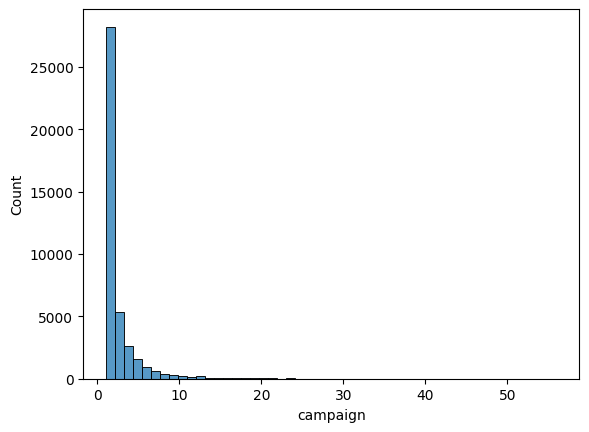

In [39]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins= 50
    )

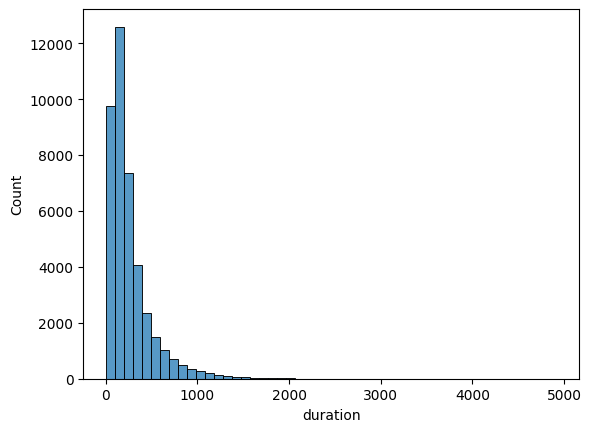

In [40]:
fig = sns.histplot(
    data=df, 
    x="duration",
    bins= 50
    )

-------

#### Valores Categoricos

In [41]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [42]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [43]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [44]:
df['housing'].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [45]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [46]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

#### Campañas Previas

In [47]:
df['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

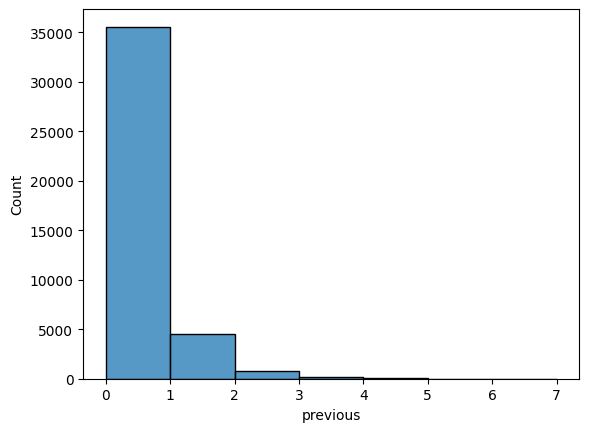

In [48]:
fig = sns.histplot(
    data=df, 
    x="previous",
    bins = 7
        )


In [49]:
df['poutcome'].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

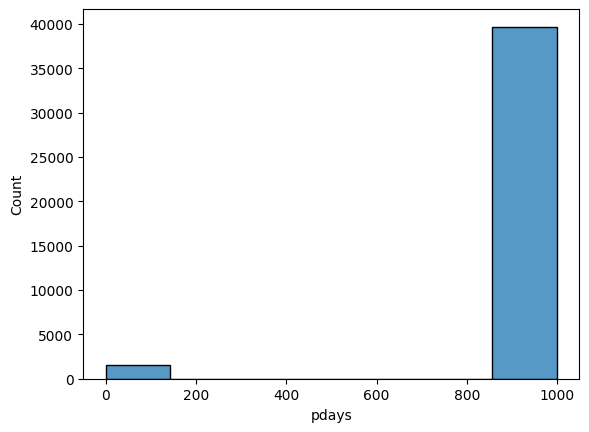

In [50]:
fig = sns.histplot(
    data=df, 
    x="pdays",
    bins = 7
        )


-----
#### Puntos de referencia - Euribor, Empleos, etc.

In [51]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].describe().round(2)

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00
mean,0.08,93.58,-40.50,3.62,5167.04
std,1.57,0.58,4.63,1.73,72.25
min,-3.40,92.20,-50.80,0.63,4963.60
25%,-1.80,93.08,-42.70,1.34,5099.10
50%,1.10,93.75,-41.80,4.86,5191.00
75%,1.40,93.99,-36.40,4.96,5228.10
max,1.40,94.77,-26.90,5.04,5228.10


In [52]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].agg(['median']).transpose()

,median
emp.var.rate,1.100
cons.price.idx,93.749
cons.conf.idx,-41.800
euribor3m,4.857
nr.employed,5191.000


-----


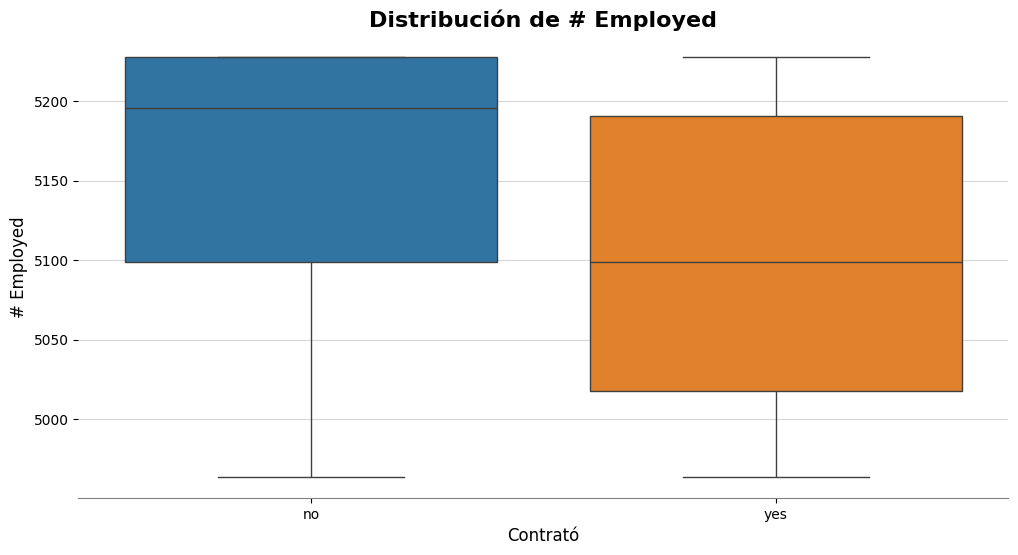

In [53]:
# configurar tamaño del plot (figsize=(12,6))
plt.figure(figsize=(12, 6))

# boxplot ventas vs mes
ax = sns.boxplot(
    data=df,
    y="nr.employed",
    x="y",
    hue="y",
    legend=False
    )

# añadir título al plot y a los ejes
ax.set_title("Distribución de # Employed", fontsize=16, fontweight="bold")
ax.set_xlabel("Contrató", fontsize=12)
ax.set_ylabel("# Employed", fontsize=12)

# personalizar el grid de fondo
ax.grid(alpha=0.5, drawstyle="steps", axis="y", linestyle="-")

# personalizar el marco del plot (spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("gray")

# show plot
plt.show()

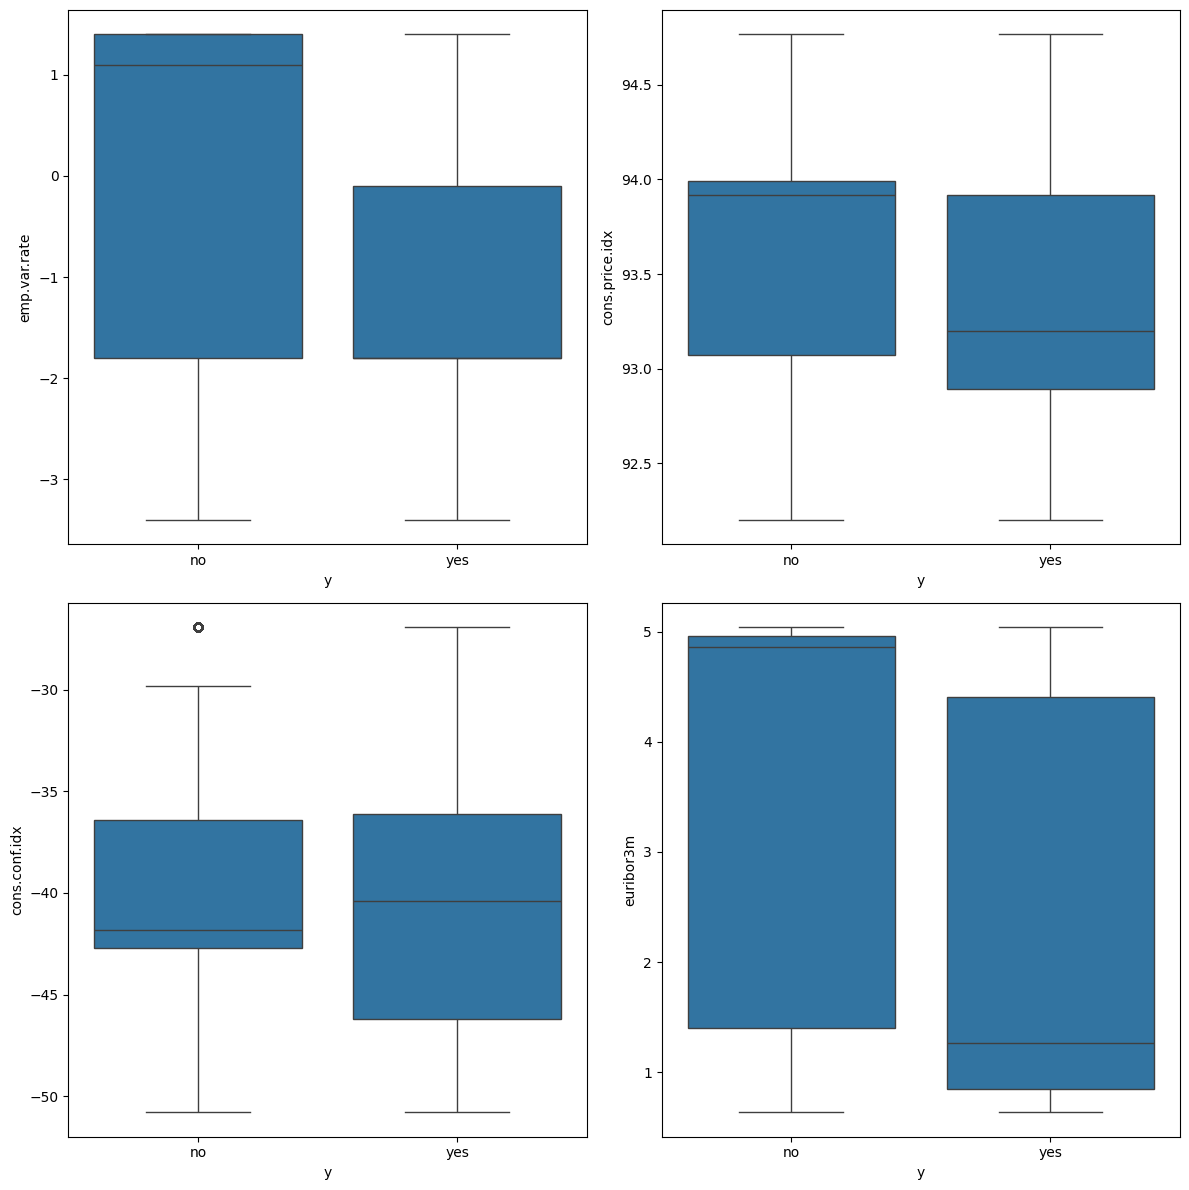

In [54]:
# iniciar el grid para el plot (3, 3, figsize=(12, 6))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# aplanar todos los axes para poder recorrerlos todos en un solo bucle
axes_flat = axes.flatten()

# pintar cada scatterplot de forma 
lag_cols = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

for i, ax in enumerate(axes_flat):
    sns.boxplot(
        data=df,
        y=lag_cols[i],
        x="y",
        legend=False,
        ax=ax,  # pintamos sobre un ax ya existente
        )
    
# ajustar espacio entre plots
plt.tight_layout()

[⬆ Volver al índice](#indice)

<a id="analisis"></a>
## Análisis de los datos 🧠

### Tasa de Conversión Total

La tasa de conversión total de la campaña es **11%.**

In [55]:
df['y'].value_counts(normalize= True).round(2).reset_index().query('y=="yes"')['proportion']

1    0.11
Name: proportion, dtype: float64

### Empleos

Cúales tipos de empleos tienen las personas contactadas, y cúanta gente en total hay en cada grupo?

In [56]:
df.groupby('job')['y'].count().reset_index().rename({'y':'contacts'}, axis = 'columns').sort_values(by = 'contacts', ascending= False)

,job,contacts
0,admin.,10422
1,blue-collar,9254
9,technician,6743
7,services,3969
4,management,2924
5,retired,1720
2,entrepreneur,1456
6,self-employed,1421
3,housemaid,1060
10,unemployed,1014


/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_89126/2289671376.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


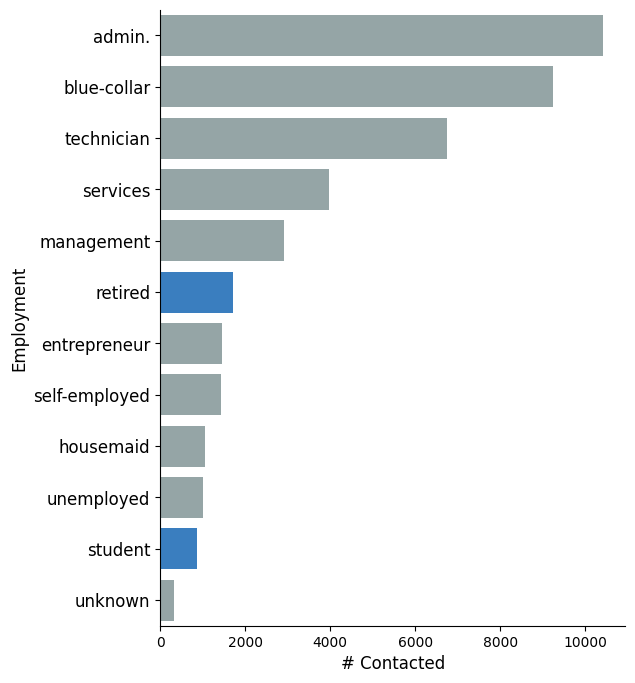

In [57]:
fig, ax = plt.subplots(figsize=(6, 8))

df.groupby('job')['y'].count()

# df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion')

ax = sns.barplot(
    df.groupby('job')['y'].count().reset_index().sort_values(by = 'y', ascending= False),
    x = 'y',
    y = 'job'
)

ax.set(xlabel='# Contracted', ylabel='Employment')

ax.set_xlabel(xlabel='# Contacted', fontsize = 12)
ax.set_ylabel(ylabel='Employment', fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

for i, patch in enumerate(ax.patches):
    label = ax.get_yticklabels()[i].get_text()
    if label in ['student','retired']:
        patch.set_facecolor('#3a7ebf')
    else:
        patch.set_facecolor('#95a5a6')

sns.despine(right=True)

plt.show()

Qué es la proporción de gente que dijó "Sí" basado a nuestro contacto, por trabajo?

In [58]:
df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion').rename(columns={'no':'No','yes':'Contracted'})

y,No,Contracted
job,,
admin.,0.87,0.13
blue-collar,0.93,0.07
entrepreneur,0.91,0.09
housemaid,0.90,0.10
management,0.89,0.11
retired,0.75,0.25
self-employed,0.90,0.10
services,0.92,0.08
student,0.69,0.31


/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_89126/726666947.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


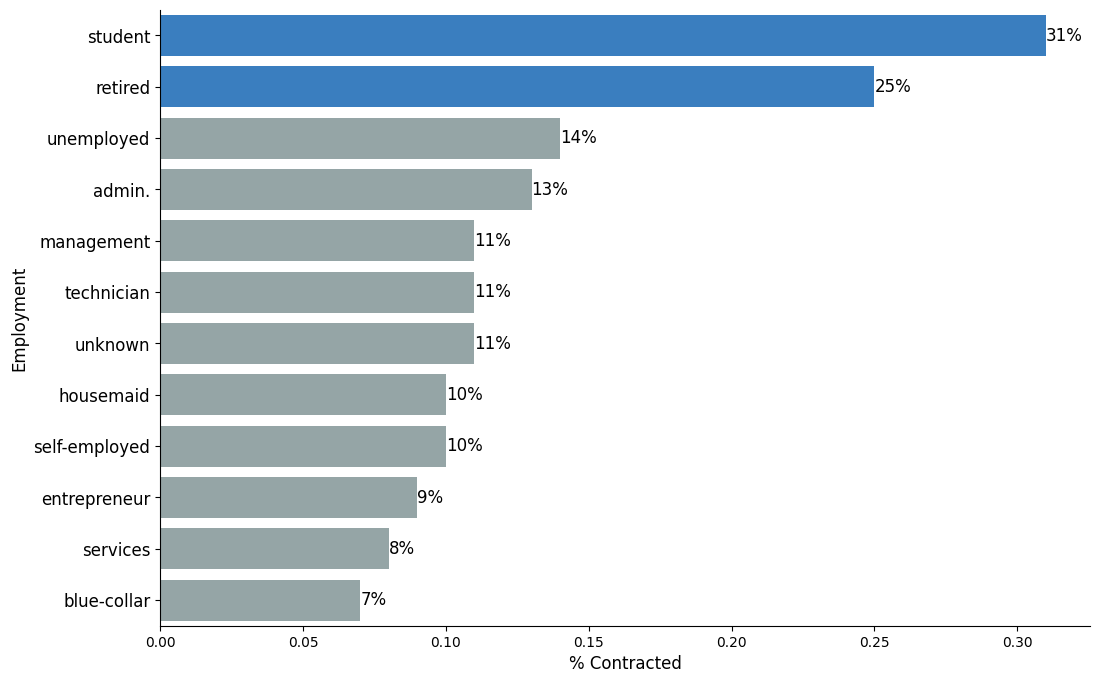

In [59]:
fig, ax = plt.subplots(figsize=(12, 8))

ax = sns.barplot(
    df.groupby('job')['y']
      .value_counts(normalize=True)
      .round(2)
      .reset_index()
      .pivot(index='job', columns='y', values='proportion')
      .sort_values(by='yes', ascending=False),
    x='yes',
    y='job',
)

ax.set_xlabel(xlabel='% Contracted', fontsize = 12)
ax.set_ylabel(ylabel='Employment', fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fmt=lambda x: f'{x:.0%}')

for i, patch in enumerate(ax.patches):
    if i < 2:
        patch.set_facecolor("#3a7ebf") 
    else:
        patch.set_facecolor('#95a5a6') 

sns.despine(right=True)


plt.show()

### Estado Civil

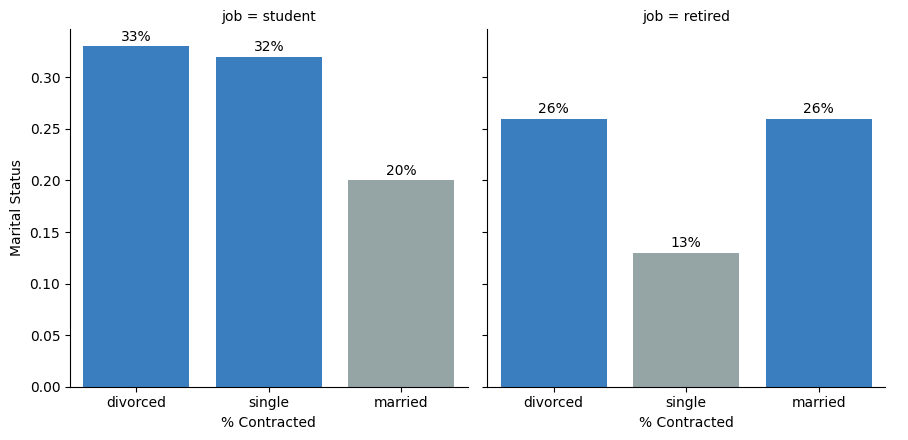

In [60]:
ax = sns.catplot(
    data= df.query('job == "student" | job == "retired"')
        .groupby(['marital','job'])['y']
        .value_counts(normalize= True)
        .round(2).reset_index().query('marital != "unknown"')
        .pivot(index= ['marital','job'], columns = 'y', values = 'proportion')
        .sort_values(by = 'yes', ascending= False),
    x= "marital", 
    y= "yes", 
    col= "job",
    kind="bar", height=4.5, aspect=1
)

for ax in ax.axes.flat:
    ax.set(xlabel='% Contracted', ylabel='Marital Status')
    for container in ax.containers:
        for bar in container:
            if bar.get_height() > 0.25:
                bar.set_facecolor('#3a7ebf')  # highlight color
            else:
                bar.set_facecolor('#95a5a6')  # muted default
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}', padding= 2)

plt.show()

#### Duración de Llamada

Cambiamos los segundos a minutos.

In [61]:
df['duration_minutes'] = df['duration'] / 60

El promedio de las llamadas son a 4.3 minutos.

In [62]:
df.duration.describe() / 60

count    686.466667
mean       4.304750
std        4.321321
min        0.000000
25%        1.700000
50%        3.000000
75%        5.316667
max       81.966667
Name: duration, dtype: float64

In [63]:
bins = [0, 60, 300, 600, np.inf]
names = ['0-1 min', '1-5 min', '5-10 min', '10 min+']

df['duration_segment'] = pd.cut(df['duration'], bins, labels=names)

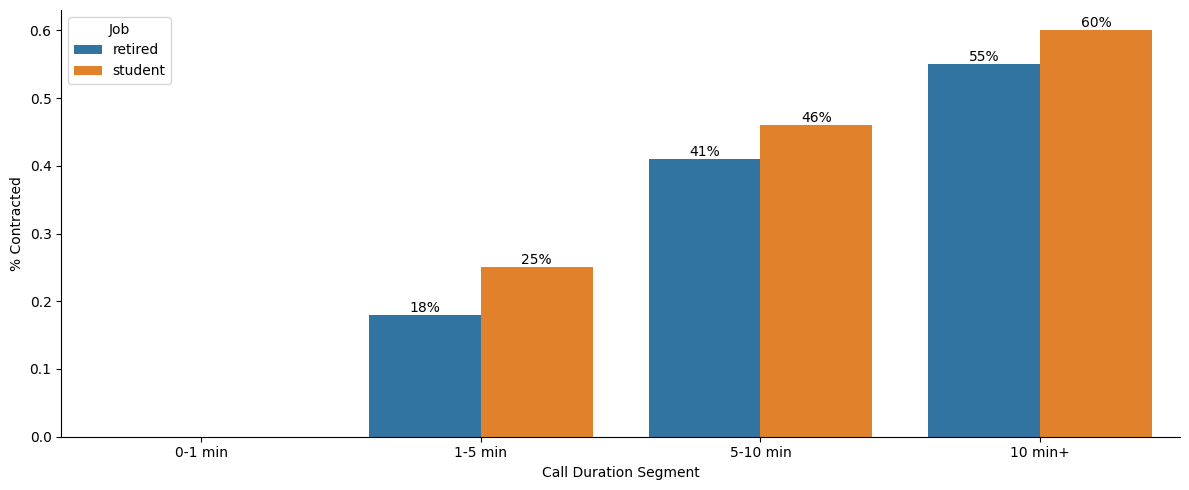

In [64]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df.query('job == "student" | job == "retired"')
           .groupby(['job', 'duration_segment'], observed=True)['y']
           .value_counts(normalize=True)
           .round(2)
           .reset_index()
           .query('y == "yes"'),
    x='duration_segment',
    y='proportion',
    hue='job',
    ax=ax
)

ax.set(ylabel='% Contracted', xlabel='Call Duration Segment')
plt.legend(title='Job')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

sns.despine(right=True, top= True)

plt.tight_layout()
plt.show()

### Intentos Previos

Categorizamos los clientes si lo habíamos contactado anteriormente: 
- Prospect, si nunca le hayamos contactado.
- Retargeting, si les hayamos contactado por lo menos una (1) vez.

In [65]:
df['previously_attempted'] = df['previous'].apply(lambda x: previouslyContacted(x))

In [66]:
df['previously_attempted'].value_counts()

previously_attempted
Prospect       35563
Retargeting     5625
Name: count, dtype: int64

/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_89126/3398248726.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


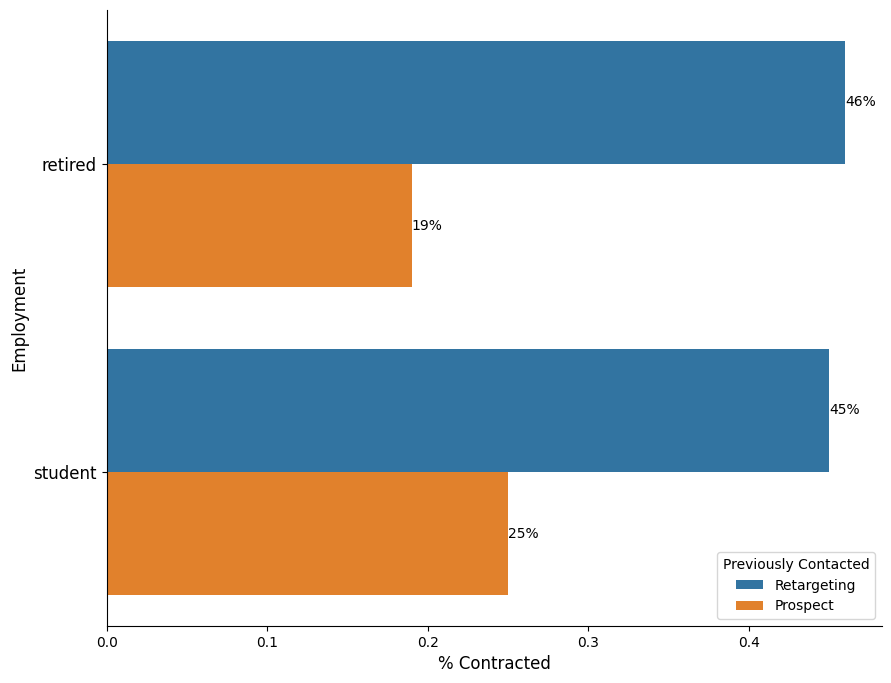

In [75]:
ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.query('job == "student" | job == "retired"')
    .groupby(['job','previously_attempted'])['y']
    .value_counts(normalize= True)
    .round(2).reset_index()
    .pivot(index= ['job','previously_attempted'], columns = 'y', values = 'proportion')
    .sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'previously_attempted'
)

ax.set_xlabel(xlabel='% Contracted', fontsize = 12)
ax.set_ylabel(ylabel='Employment', fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Previously Contacted')



sns.despine(right=True, top= True)

plt.show()

In [87]:
def number_of_contacts(value):
    if value >= 5:
        return 'Greater Than 5'
    else:
        return value

df['number_contacts'] = df['campaign'].apply(lambda x: number_of_contacts(x))

In [89]:
df['number_contacts'].sample(n = 15)

24433                 1
22891                 3
38792                 2
14826                 1
41143                 1
6993                  1
16664                 2
28310    Greater Than 5
26130                 3
17063    Greater Than 5
9810                  1
5016     Greater Than 5
18680                 3
1528                  2
20330    Greater Than 5
Name: number_contacts, dtype: object

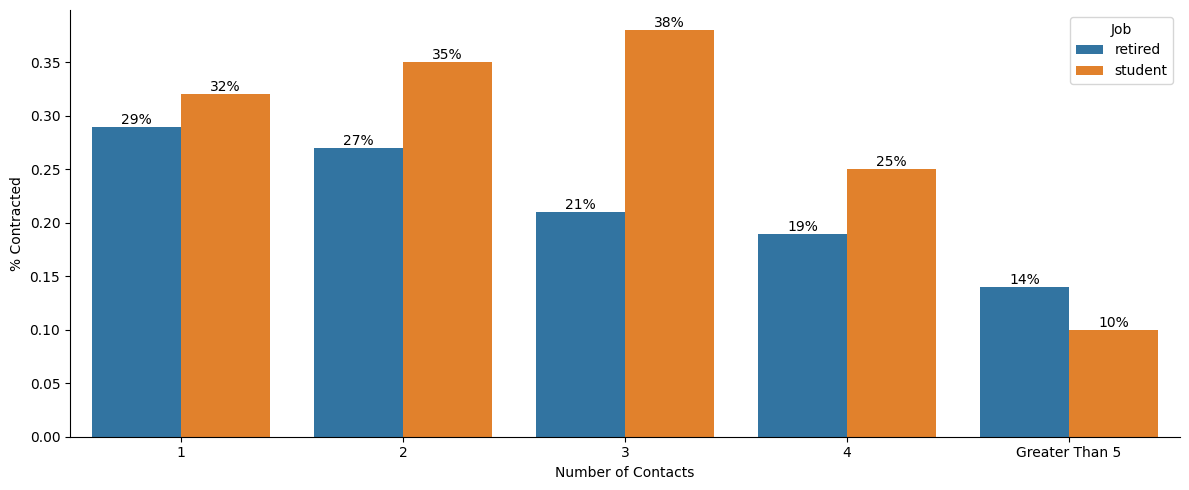

In [92]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df.query('job == "student" | job == "retired"')
           .groupby(['job', 'number_contacts'], observed=True)['y']
           .value_counts(normalize=True)
           .round(2)
           .reset_index()
           .query('y == "yes"'),
    x='number_contacts',
    y='proportion',
    hue='job',
    ax=ax
)

ax.set(ylabel='% Contracted', xlabel='Number of Contacts')
plt.legend(title='Job')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

sns.despine(right=True, top= True)

plt.tight_layout()
plt.show()

### Duración de Llamada

Analisando la tasa de conversión con la duración de la llamada.

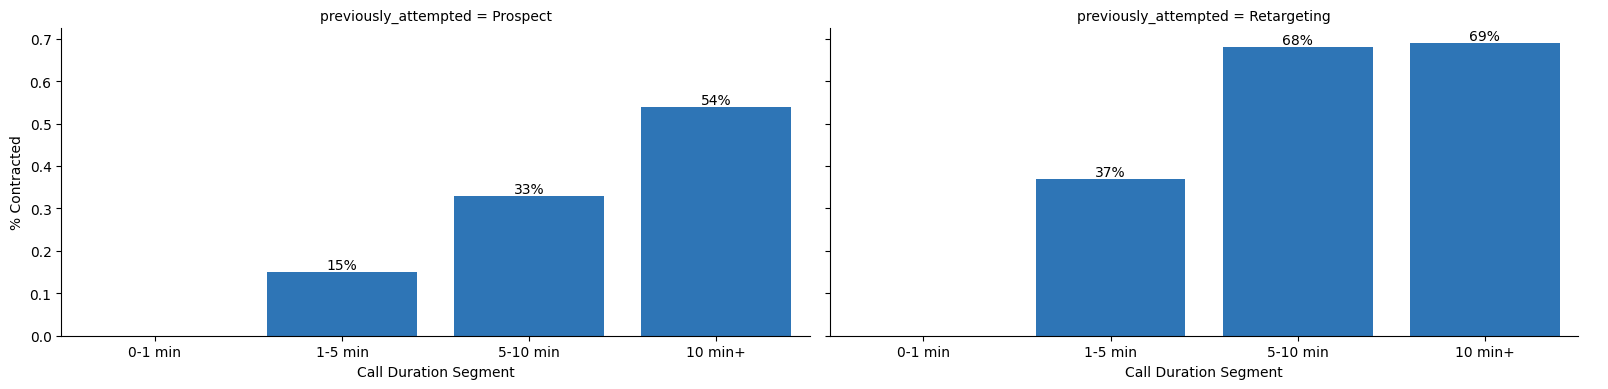

In [68]:
ax = sns.catplot(
    data= df.query('job == "student" | job == "retired"')
        .groupby(['previously_attempted','duration_segment'], observed= True)['y']
        .value_counts(normalize= True)
        .round(2).reset_index()
        .query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "previously_attempted",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Call Duration Segment')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')
        for bar in container:
            bar.set_facecolor('#2e75b6')

sns.despine(right=True, top= True)

plt.show()

### Clientes Existentes

Analisamos si clientes 'student' o 'retired' existentes son más dispuestos a contratar que gente que nos habían rechazado previamente, o gente que aún no les hemos contactado. 

/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_89126/21252215.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


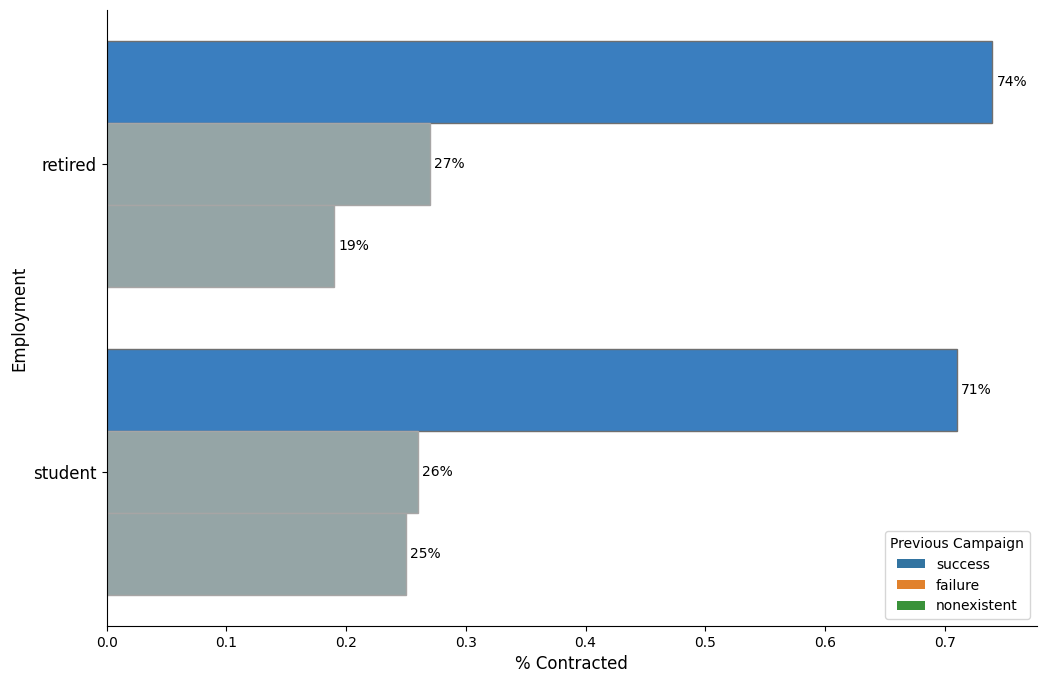

In [76]:
ax = plt.subplots(figsize=(12, 8))

ax = sns.barplot(
    df.query('job == "student" | job == "retired"')
    .groupby(['job','poutcome'])['y']
    .value_counts(normalize= True)
    .round(2).reset_index()
    .pivot(index= ['job','poutcome'], columns = 'y', values = 'proportion')
    .sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'poutcome'
)

ax.set_xlabel(xlabel='% Contracted', fontsize = 12)
ax.set_ylabel(ylabel='Employment', fontsize = 12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)

plt.legend(title='Previous Campaign')

for container in ax.containers:
    for bar in container:
        if bar.get_width() > 0.50:        
            bar.set_facecolor('#3a7ebf')
            bar.set_edgecolor("#6F6F6F")
        else:
            bar.set_facecolor('#95a5a6')
            bar.set_edgecolor("#A7A5A5")
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}', padding= 3)

sns.despine(right=True, top= True)

plt.show()

Analizamos la relación entre la tasa de conversión y la duración de la llamada.

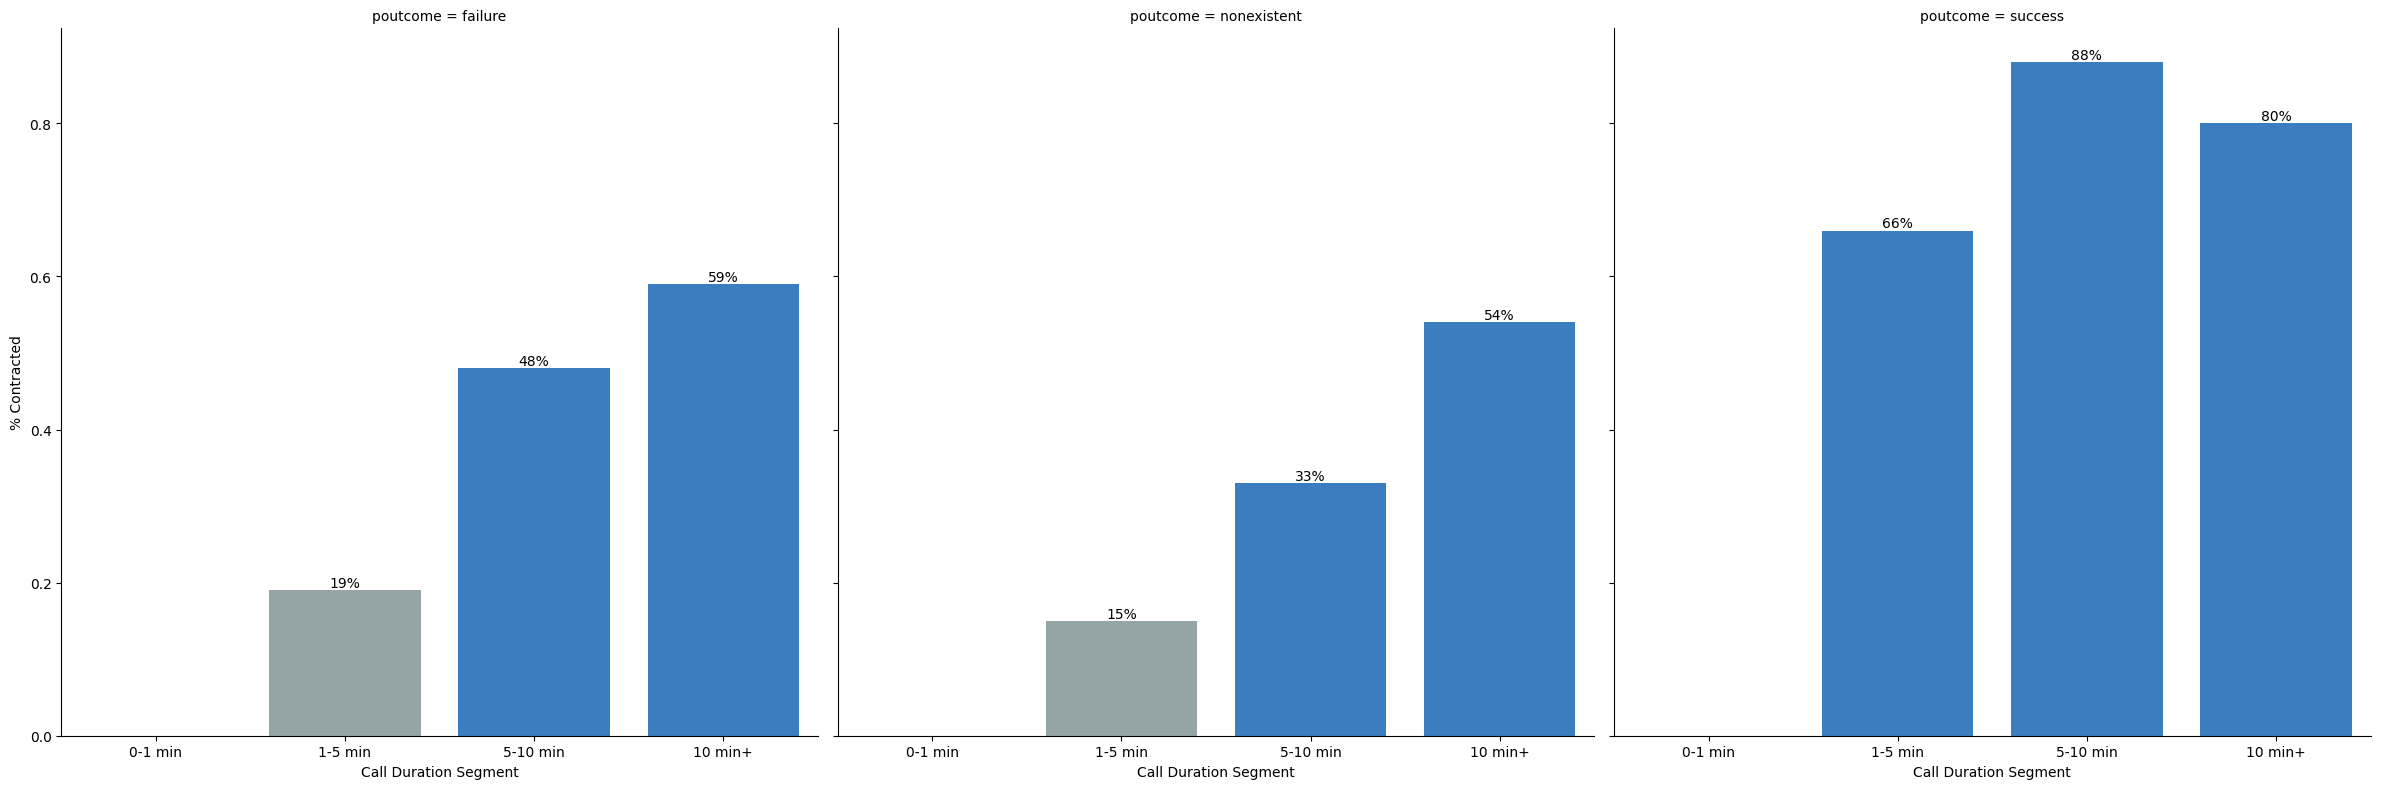

In [70]:
ax = sns.catplot(
    data= df.query('job == "student" | job == "retired"')
        .groupby(['poutcome','duration_segment'], observed= True)['y']
        .value_counts(normalize= True)
        .round(2).reset_index()
        .query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "poutcome",
    kind="bar", height=8, aspect=1
)

for ax in ax.axes.flat:
    ax.set(xlabel='Call Duration Segment', ylabel='% Contracted')
    for container in ax.containers:
        for bar in container:
            if bar.get_height() > 0.30:
                bar.set_facecolor('#3a7ebf')  
            else:
                bar.set_facecolor('#95a5a6') 
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

### Campaña Corriente - Mes o Día de la Semana y Cuantas veces hemos contactado

In [71]:
df['season'] = df['month'].apply(lambda x: seasons(x))

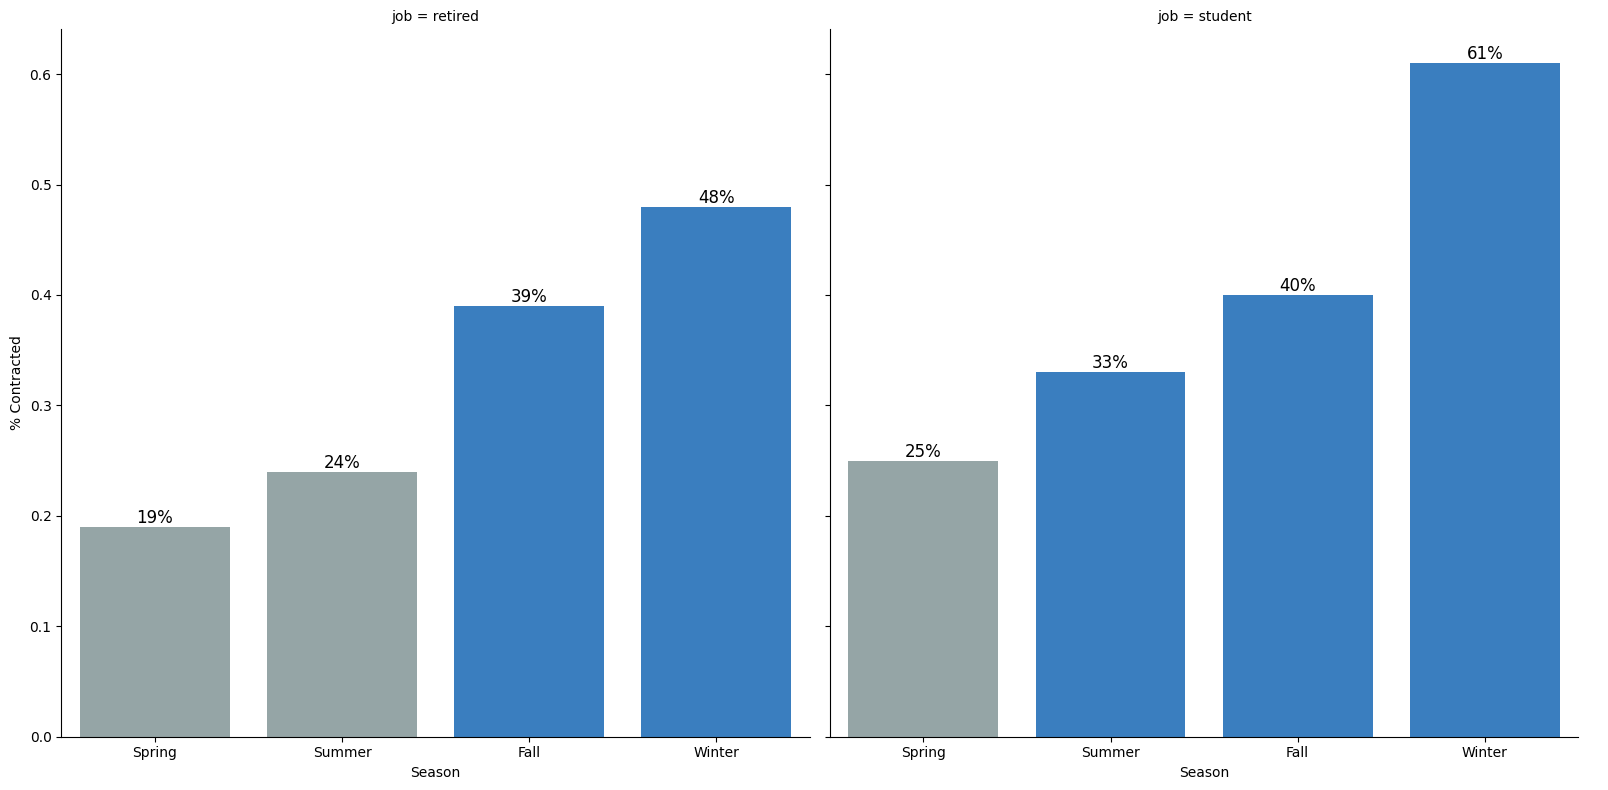

In [82]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

season_df = df.query('job == "student" | job == "retired"').groupby(['job','season'], observed= True)['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"')

season_df['season'] = pd.Categorical(season_df['season'], categories=season_order, ordered=True)
season_df = season_df.sort_values('season')

g = sns.catplot(
    data= season_df,
    x= "season", 
    y= "proportion", 
    col= "job",
    kind="bar", height=8, aspect=1,
    order = season_order
)


for ax in g.axes.flat:
    ax.set(xlabel='Season', ylabel='% Contracted')
    for container in ax.containers:
        for bar in container:
            if bar.get_height() > 0.30:
                bar.set_facecolor('#3a7ebf')  
            else:
                bar.set_facecolor('#95a5a6') 
        ax.bar_label(container, fontsize=12, fmt=lambda x: f'{x:.0%}')


plt.show()

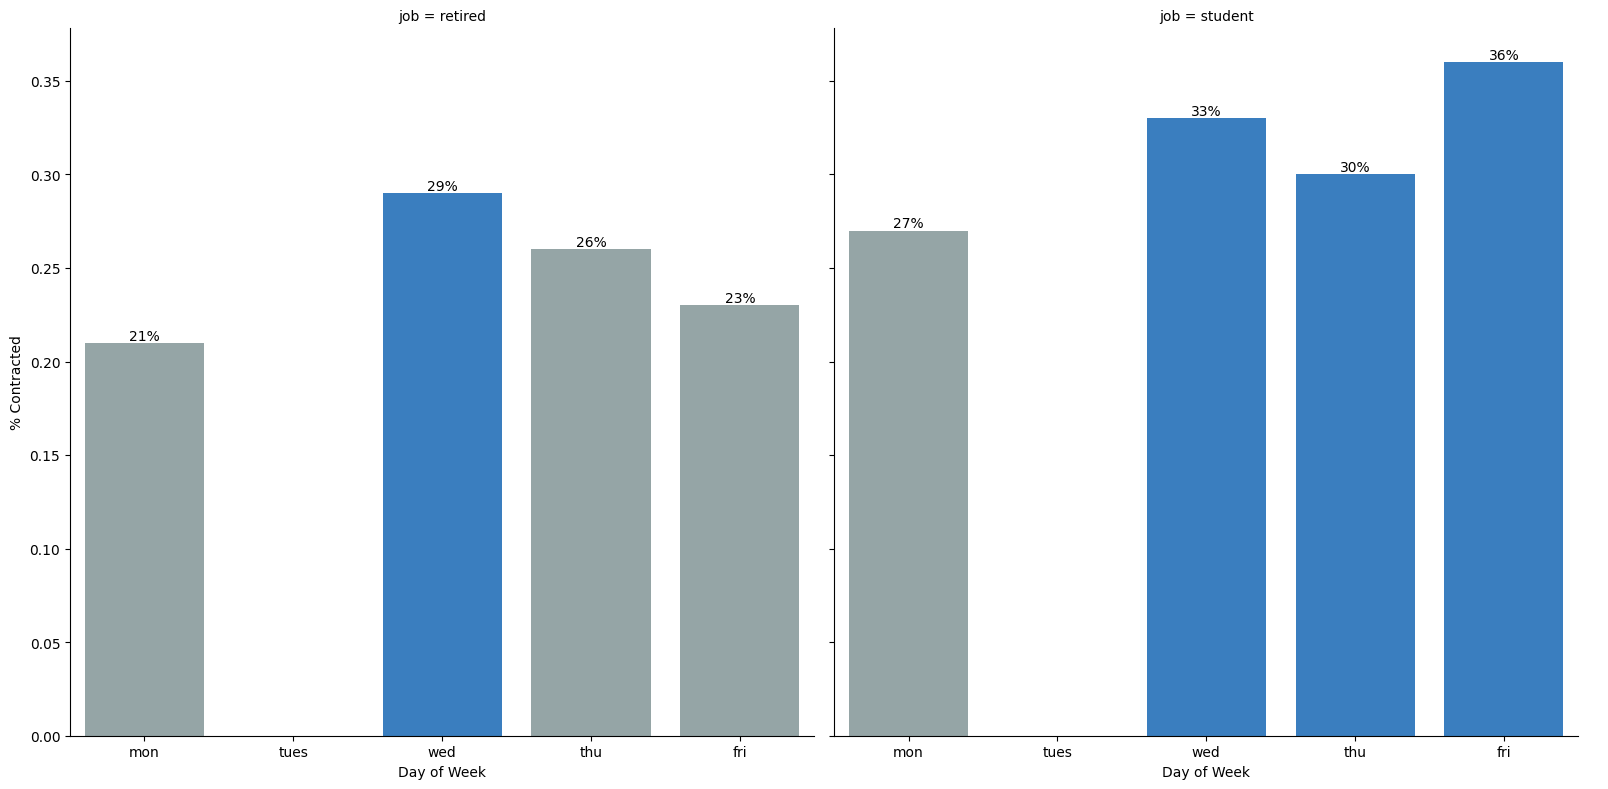

In [73]:
weekday_order = ['mon', 'tues', 'wed', 'thu','fri']

weekday_df = df.query('job == "student" | job == "retired"').groupby(['job','day_of_week'], observed= True)['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"')

weekday_df['day_of_week'] = pd.Categorical(weekday_df['day_of_week'], categories=weekday_order, ordered=True)
weekday_df = weekday_df.sort_values('day_of_week')

g = sns.catplot(
    data= weekday_df,
    x= "day_of_week", 
    y= "proportion", 
    col= "job",
    kind="bar", height=8, aspect=1,
    order = weekday_order
)

for ax in g.axes.flat:
    ax.set(xlabel='Day of Week', ylabel='% Contracted')
    for container in ax.containers:
        for bar in container:
            if bar.get_height() > 0.28:
                bar.set_facecolor('#3a7ebf')  
            else:
                bar.set_facecolor('#95a5a6') 
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

[⬆ Volver al índice](#indice)

<a id="conclusiones"></a>

## Conclusiones del Análisis Exploratorio de Datos (EDA) 📝

El análisis realizado nos permite identificar los principales factores que influyen en la tasa de conversión de la campaña, con el objetivo de optimizar su rendimiento. Este es el resumen con los hallazgos más relevantes:

---

### **Calidad y estructura del dataset**
El dataset presenta una buena calidad general, lo que ha facilitado el análisis:

- No se detectan valores nulos en las variables.  
- Se identifican algunos registros duplicados, con impacto reducido.  
- Existen outliers en variables como `duration`, `campaign`, `pdays` y `previous`, que deben considerarse en análisis posteriores.  

---

### **Distribución de la variable objetivo**
Se observa un claro desbalanceo en la conversión:

- Predominan los clientes que **no convierten** frente a los que sí lo hacen.  
- Este desbalance implica la necesidad de estrategias enfocadas en mejorar la captación de casos positivos.  

---

### **Variables con mayor impacto en la conversión**
Algunas variables muestran una relación directa con el éxito de la campaña:

- La **duración de la llamada (`duration`)** es el factor más influyente:  
  - A mayor duración, mayor probabilidad de conversión.  
  - No obstante, su uso predictivo es limitado (se conoce tras el contacto).  

- El número de contactos (`campaign`) no presenta una relación positiva clara con la conversión:  
  - Más intentos no implican mejores resultados.  

---

### **Segmentación por tipo de empleo (hipótesis principal)**
El análisis confirma la hipótesis planteada:

- Los segmentos de **`student` y `retired` presentan las mayores tasas de conversión**.  
- Estos grupos constituyen los **targets prioritarios** para optimizar la campaña.  

---

### **Influencia del momento del contacto**
El rendimiento de la campaña depende también del timing:

- Existen diferencias en la conversión según el **día de la semana**. De miércoles a viernes es cuando más convierte y, por el contrario, el martes no es recomendable contactar.
- También se observan variaciones según el **mes o estación del año**. Invierno es la mejor época para contactar.

➡️ Esto indica que una mejor planificación temporal puede incrementar significativamente la efectividad.

---

### **Importancia del historial de contacto (retargeting)**
El comportamiento previo del cliente es clave:

- Los clientes contactados anteriormente tienen **mayor probabilidad de conversión**.  
- Este efecto es más fuerte cuando el resultado previo fue positivo (`poutcome = success`).  

➡️ El **retargeting se posiciona como una estrategia más efectiva** que la captación de nuevos clientes.

---

### **Frecuencia de contacto**
El número de interacciones no es determinante por sí solo:

- La mayoría de clientes han sido contactados pocas veces.  
- Incrementar la frecuencia no garantiza mejores resultados.  

➡️ La **calidad y el momento del contacto** son más relevantes que la cantidad.

---

## **Recomendaciones generales**

En conjunto, el EDA sugiere que la optimización de la campaña debe centrarse en:

- Priorizar segmentos de alto valor (**students y retired**).  
- Optimizar el **timing del contacto** (día y periodo del año).  
- Potenciar estrategias de **retargeting**.  
- Focalizar en la **efectividad del contacto**, no en aumentar su volumen.  

[⬆ Volver al índice](#indice)

<a id="machine-learning"></a>
## Machine Learning 🤖

En esta sección se desarrollan distintos modelos de clasificación supervisada para predecir la probabilidad de que un cliente suscriba un depósito a plazo.

Dado que la variable objetivo presenta un desbalance entre clases, se comparan dos estrategias para abordar este problema:

- **Class Weight = balanced**, que ajusta el peso de cada clase durante el entrenamiento.
- **SMOTE**, que genera observaciones sintéticas de la clase minoritaria en el conjunto de entrenamiento.

Se implementan tres algoritmos:

- Logistic Regression
- Decision Tree
- Random Forest

La comparación se realiza mediante varias métricas: Accuracy, Precision, Recall, F1 Score y ROC AUC.

### Librerías

Se importan las librerías necesarias para preprocesar los datos, construir pipelines, entrenar modelos, evaluar resultados y tratar el desbalance de clases.

In [48]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

Tras la fase de análisis exploratorio de datos y la preparación del dataset, el siguiente paso consiste en aplicar técnicas de Machine Learning supervisado con el objetivo de construir un modelo capaz de predecir la probabilidad de que un cliente contrate un depósito a plazo tras una campaña de marketing telefónico.

La variable objetivo del modelo es y, que indica si el cliente ha suscrito el depósito (yes) o no (no). Esta variable depende de diferentes factores relacionados con:

- características sociodemográficas del cliente (edad, empleo, estado civil, educación),

- situación financiera (préstamos, hipotecas, historial de crédito),

- características de la campaña de marketing,

- indicadores macroeconómicos.

Dado que la variable objetivo presenta únicamente dos categorías posibles, el problema se aborda como un problema de clasificación binaria.

El desarrollo de modelos predictivos permite a las entidades financieras:

- identificar clientes con mayor probabilidad de conversión,

- optimizar las campañas de marketing directo,

- reducir los costes asociados a llamadas innecesarias,

- mejorar la eficiencia comercial de la organización.

In [49]:
df = pd.read_csv('../Data/bank-additional_bank-additional-full.csv', sep=';')

### Objetivo del Modelo

### Separación de variables

Se separan las variables predictoras de la variable objetivo. La variable y se convierte a formato binario para que pueda ser utilizada por los algoritmos de clasificación.

In [50]:
X = df.drop(columns=["y"])
y = df["y"].map({"yes": 1, "no": 0})

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nDistribución de la variable objetivo:")
print(y.value_counts())
print("\nDistribución relativa:")
print(y.value_counts(normalize=True))

Dimensiones de X: (41188, 20)
Dimensiones de y: (41188,)

Distribución de la variable objetivo:
y
0    36548
1     4640
Name: count, dtype: int64

Distribución relativa:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


### Comentario sobre el desbalance

Se comprueba el desbalance de la variable objetivo, ya que este afecta directamente al entrenamiento de los modelos y justifica el uso de técnicas como class_weight y SMOTE.

### 4.1 Desbalance de clases

La variable objetivo presenta un claro desbalance entre clientes que no contratan el depósito y clientes que sí lo contratan.

Este tipo de distribución puede sesgar el entrenamiento de los modelos hacia la clase mayoritaria, dificultando la detección de la clase minoritaria. Por este motivo, en este trabajo se aplican dos estrategias de corrección del desbalance:

- ajuste de pesos mediante `class_weight="balanced"`
- generación de observaciones sintéticas mediante `SMOTE`

El objetivo es mejorar la capacidad del modelo para detectar correctamente a los clientes que sí contratarían el producto.

### Train/Test split

El dataset se divide en entrenamiento y test. La división se hace antes de aplicar cualquier técnica de balanceo para evitar fuga de información. Se utiliza stratify=y para conservar la proporción original de clases en ambos subconjuntos.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribución de y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de y_test:")
print(y_test.value_counts(normalize=True))

X_train: (32950, 20)
X_test : (8238, 20)
y_train: (32950,)
y_test : (8238,)

Distribución de y_train:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Distribución de y_test:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Identificación de variables numéricas y categóricas

Se identifican automáticamente las variables numéricas y categóricas, ya que cada tipo necesita un tratamiento distinto en el preprocesado.

In [52]:
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Preprocesado

Se construye un preprocesador que aplica transformaciones distintas según el tipo de variable. En las variables numéricas se imputan posibles nulos y se escalan. En las categóricas se imputan posibles nulos y se codifican mediante One-Hot Encoding.

Aunque el dataset original no tenga nulos, se mantiene la imputación por robustez metodológica.

In [53]:
numeric_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = SklearnPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Explicación del preprocesado

Se deja una breve explicación metodológica de por qué se usa este pipeline y cómo se integra después con los modelos.

### 4.2 Preprocesado de datos

El preprocesado se realiza mediante un `ColumnTransformer`, lo que permite aplicar transformaciones específicas a cada tipo de variable:

- Las variables numéricas se imputan con la mediana y se escalan.
- Las variables categóricas se imputan con la categoría más frecuente y se transforman mediante One-Hot Encoding.

Este enfoque garantiza que el dataset quede completamente numérico y preparado para el entrenamiento de los modelos. Además, al integrarse dentro del pipeline, asegura consistencia entre entrenamiento, validación y predicción.

### Definición de modelos con class_weight balanced

Se definen tres modelos con class_weight="balanced". Esta estrategia da más peso a la clase minoritaria durante el entrenamiento para compensar el desbalance sin modificar los datos.

In [54]:
models_balanced = {
    "Logistic Regression (balanced)": SklearnPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Decision Tree (balanced)": SklearnPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Random Forest (balanced)": SklearnPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

### Definición de modelos con SMOTE

Se definen los mismos tres modelos, pero ahora incorporando SMOTE dentro del pipeline. De este modo, el oversampling se aplica solo al conjunto de entrenamiento y nunca al test.

In [55]:
smote = SMOTE(
    sampling_strategy=0.67,   # aprox. 60-40
    random_state=42,
    k_neighbors=5
)

models_smote = {
    "Logistic Regression (SMOTE)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    "Decision Tree (SMOTE)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
    ]),
    
    "Random Forest (SMOTE)": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

### Explicación de las dos estrategias

Se justifica brevemente por qué se comparan ambas estrategias y qué diferencia conceptual existe entre ellas.

### 4.3 Tratamiento del desbalance

En este trabajo se comparan dos estrategias para corregir el desbalance de clases:

**1. Class Weight = balanced**  
Esta técnica no modifica el dataset, sino que asigna más peso a la clase minoritaria durante el entrenamiento. De esta forma, el modelo penaliza más los errores sobre dicha clase.

**2. SMOTE**  
Esta técnica genera observaciones sintéticas de la clase minoritaria en el conjunto de entrenamiento, aumentando su representación y facilitando el aprendizaje del modelo.

La comparación entre ambas estrategias permite identificar cuál ofrece mejores resultados en términos de detección de clientes potenciales.

### Función de evaluación

Se crea una función para entrenar y evaluar todos los modelos de forma homogénea. Se incluyen todas las métricas importantes: Accuracy, Precision, Recall, F1 y ROC AUC.

In [56]:
def evaluate_models(models_dict, X_train, X_test, y_train, y_test):
    results = []
    fitted_models = {}
    
    for name, model in models_dict.items():
        print("=" * 80)
        print(f"MODELO: {name}")
        print("=" * 80)
        
        # Entrenamiento
        model.fit(X_train, y_train)
        fitted_models[name] = model
        
        # Predicción
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        # Métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_proba)
        
        results.append({
            "Modelo": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "ROC AUC": auc
        })
        
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(f"ROC AUC  : {auc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))
    
    results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
    return results_df, fitted_models

### Entrenar y evaluar modelos balanced

Se entrenan y evalúan los modelos que corrigen el desbalance mediante pesos balanceados.

In [57]:
results_balanced_df, fitted_balanced = evaluate_models(
    models_balanced, X_train, X_test, y_train, y_test
)

display(results_balanced_df)

MODELO: Logistic Regression (balanced)
Accuracy : 0.8651
Precision: 0.4512
Recall   : 0.9116
F1 Score : 0.6036
ROC AUC  : 0.9438

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

MODELO: Decision Tree (balanced)
Accuracy : 0.8460
Precision: 0.4160
Recall   : 0.9095
F1 Score : 0.5708
ROC AUC  : 0.9398

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      7310
           1       0.42      0.91      0.57       928

    accuracy                           0.85      8238
   macro avg       0.70      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238

MODELO: Random Forest (balanced)
Accuracy : 0.

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression (balanced),0.865137,0.451200,0.911638,0.603639,0.943838
1,Random Forest (balanced),0.853727,0.430646,0.926724,0.588034,0.945505
2,Decision Tree (balanced),0.845958,0.415968,0.909483,0.570849,0.939777


### Entrenar y evaluar modelos SMOTE

Se entrenan y evalúan los modelos que corrigen el desbalance mediante SMOTE.

In [58]:
results_smote_df, fitted_smote = evaluate_models(
    models_smote, X_train, X_test, y_train, y_test
)

display(results_smote_df)

MODELO: Logistic Regression (SMOTE)
Accuracy : 0.8865
Precision: 0.4978
Recall   : 0.8524
F1 Score : 0.6285
ROC AUC  : 0.9434

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      7310
           1       0.50      0.85      0.63       928

    accuracy                           0.89      8238
   macro avg       0.74      0.87      0.78      8238
weighted avg       0.93      0.89      0.90      8238

MODELO: Decision Tree (SMOTE)
Accuracy : 0.8786
Precision: 0.4785
Recall   : 0.8653
F1 Score : 0.6163
ROC AUC  : 0.9369

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      7310
           1       0.48      0.87      0.62       928

    accuracy                           0.88      8238
   macro avg       0.73      0.87      0.77      8238
weighted avg       0.92      0.88      0.89      8238

MODELO: Random Forest (SMOTE)
Accuracy : 0.9013
Prec

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest (SMOTE),0.901311,0.542063,0.798491,0.645752,0.947674
1,Logistic Regression (SMOTE),0.886502,0.497797,0.852371,0.628526,0.943363
2,Decision Tree (SMOTE),0.878611,0.478546,0.865302,0.616270,0.936912


### Comparación conjunta de todos los modelos

Se unifican los resultados para comparar directamente las dos estrategias de balanceo en los tres algoritmos.

In [59]:
results_all = pd.concat([results_balanced_df, results_smote_df], ignore_index=True)
results_all = results_all.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

display(results_all)

,Modelo,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest (SMOTE),0.901311,0.542063,0.798491,0.645752,0.947674
1,Logistic Regression (SMOTE),0.886502,0.497797,0.852371,0.628526,0.943363
2,Decision Tree (SMOTE),0.878611,0.478546,0.865302,0.616270,0.936912
3,Logistic Regression (balanced),0.865137,0.451200,0.911638,0.603639,0.943838
4,Random Forest (balanced),0.853727,0.430646,0.926724,0.588034,0.945505
5,Decision Tree (balanced),0.845958,0.415968,0.909483,0.570849,0.939777


### Explicación de métricas

Se añade una breve interpretación de las métricas utilizadas, justificando especialmente el uso de Precision, Recall y F1 Score.

### 4.4 Métricas de evaluación

Para comparar los modelos se utilizan las siguientes métricas:

- **Accuracy**: proporción total de predicciones correctas.
- **Precision**: proporción de clientes predichos como positivos que realmente lo son.
- **Recall**: capacidad del modelo para detectar correctamente a los clientes que sí contratan el producto.
- **F1 Score**: media armónica entre precision y recall.
- **ROC AUC**: capacidad del modelo para discriminar entre ambas clases.

Dado el desbalance de clases, las métricas más relevantes son **Precision**, **Recall** y **F1 Score**, ya que permiten evaluar el rendimiento del modelo sobre la clase minoritaria de forma más realista que la accuracy.

### Validación cruzada

Se aplica validación cruzada a todos los modelos para comprobar la estabilidad de sus resultados. En el caso de SMOTE, el pipeline completo se valida conjuntamente para evitar errores metodológicos.

In [60]:
cv_results = []

all_models = {}
all_models.update(models_balanced)
all_models.update(models_smote)

for name, model in all_models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    
    cv_results.append({
        "Modelo": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False).reset_index(drop=True)
display(cv_results_df)

,Modelo,CV F1 Mean,CV F1 Std
0,Logistic Regression (balanced),0.308678,0.098338
1,Logistic Regression (SMOTE),0.292242,0.094612
2,Decision Tree (balanced),0.148670,0.102846
3,Decision Tree (SMOTE),0.122234,0.070430
4,Random Forest (balanced),0.075694,0.066667
5,Random Forest (SMOTE),0.061227,0.076433


### Selección del mejor modelo

Se selecciona el mejor modelo en función del F1 Score en test. Este criterio es adecuado porque equilibra precision y recall en un problema desbalanceado.

In [61]:
best_model_name = results_all.iloc[0]["Modelo"]

if best_model_name in fitted_balanced:
    best_model = fitted_balanced[best_model_name]
else:
    best_model = fitted_smote[best_model_name]

print("Mejor modelo según F1 Score:", best_model_name)

Mejor modelo según F1 Score: Random Forest (SMOTE)


### Matriz de confusión del mejor modelo

La matriz de confusión permite analizar con detalle los aciertos y errores del mejor modelo, especialmente los falsos positivos y falsos negativos.

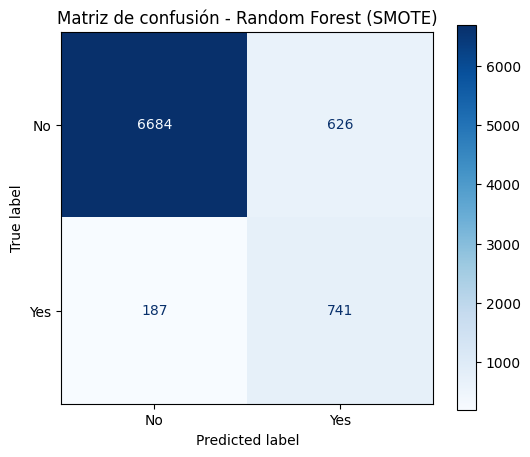

In [62]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

### Random Forest con SMOTE para importancia de variables

Aunque el mejor modelo global podría no ser Random Forest, este algoritmo se utiliza específicamente para analizar la importancia de variables, ya que ofrece una interpretación útil sobre qué factores influyen más en la predicción.

In [63]:
rf_smote = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(sampling_strategy=0.67, random_state=42, k_neighbors=5)),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_smote.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

### Importancia de variables

Se extraen las variables transformadas y sus importancias asociadas para identificar qué factores han tenido mayor peso en el modelo.

In [64]:
preprocessor_fitted = rf_smote.named_steps["preprocessor"]
rf_model = rf_smote.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(feature_importance_df.head(20))

,feature,importance
1,num__duration,0.343297
9,num__nr.employed,0.096704
8,num__euribor3m,0.089571
5,num__emp.var.rate,0.065968
7,num__cons.conf.idx,0.042188
3,num__pdays,0.032525
6,num__cons.price.idx,0.029416
44,cat__contact_telephone,0.025951
2,num__campaign,0.023188
62,cat__poutcome_success,0.021944


### Gráfico de importancia de variables

Se representa gráficamente el peso relativo de las variables más importantes para facilitar la interpretación.

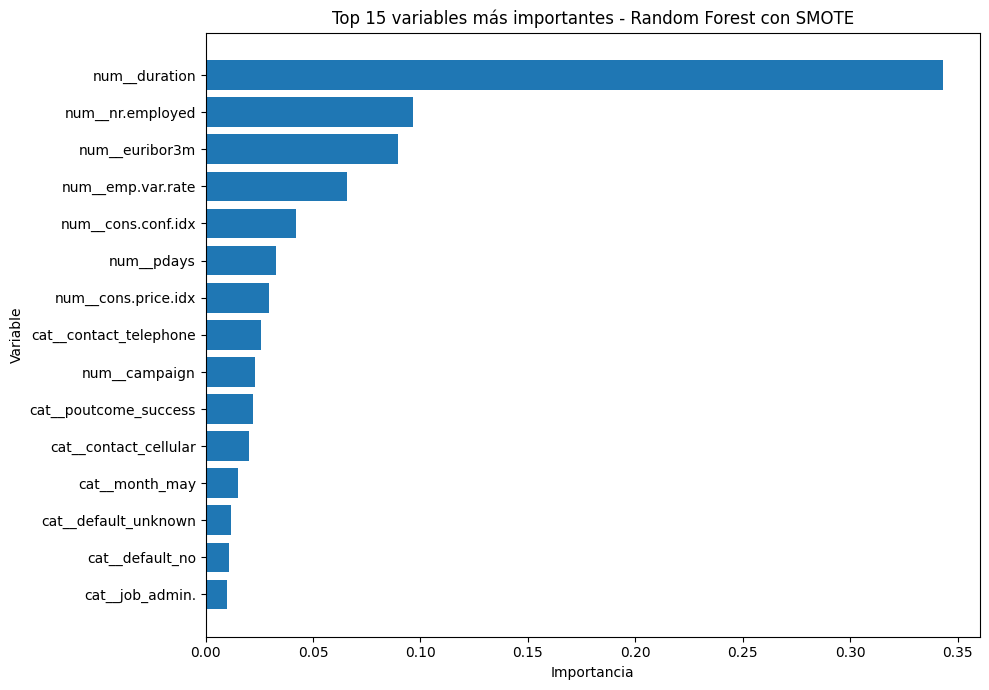

In [65]:
top_features = feature_importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 15 variables más importantes - Random Forest con SMOTE")
plt.tight_layout()
plt.show()

### Conclusión automática de resultados

Se imprime un resumen del mejor modelo encontrado y sus métricas principales.

In [66]:
best_row = results_all.iloc[0]

print("CONCLUSIÓN DEL ANÁLISIS DE MACHINE LEARNING")
print("-" * 60)
print(f"Mejor modelo: {best_row['Modelo']}")
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1 Score : {best_row['F1 Score']:.4f}")
print(f"ROC AUC  : {best_row['ROC AUC']:.4f}")

CONCLUSIÓN DEL ANÁLISIS DE MACHINE LEARNING
------------------------------------------------------------
Mejor modelo: Random Forest (SMOTE)
Accuracy : 0.9013
Precision: 0.5421
Recall   : 0.7985
F1 Score : 0.6458
ROC AUC  : 0.9477


Accuracy = 0.8955

Es alta, pero en datasets desbalanceados no es la métrica más importante. Aquí no te puedes apoyar demasiado en ella porque el modelo puede acertar muchos “no contrata” y aun así no ser excelente detectando los “sí contrata”.

Precision = 0.5216

Esto significa que, de todos los clientes que el modelo predice como “sí va a contratar”, solo alrededor del 52% realmente contratan.

Eso implica que:

hay bastantes falsos positivos

el modelo “se arriesga” a marcar clientes como potenciales aunque una parte relevante luego no convierta

Entonces, sí: la precisión no es alta. No es desastrosa, pero tampoco sobresaliente.

Recall = 0.8718

Aquí está uno de tus puntos fuertes.

Significa que el modelo detecta aproximadamente el 81% de los clientes que sí contratarían. En marketing esto suele ser muy valioso, porque perder clientes potenciales suele ser más costoso que contactar a algunos que luego no convierten.

F1 = 0.6527

Es un resultado bastante razonable para un problema desbalanceado. No es extraordinario, pero sí suficientemente sólido para defender que el modelo tiene utilidad predictiva.

ROC AUC = 0.9517

Este valor es muy bueno. Indica que el modelo tiene una capacidad de discriminación alta entre ambas clases. Es decir, a nivel de ranking/probabilidad, separa muy bien a los clientes más propensos de los menos propensos.

Aunque la precision obtenida es moderada, el modelo presenta un recall elevado, lo que indica una alta capacidad para identificar a los clientes que realmente contratarían el producto. En un contexto de marketing bancario, este resultado puede considerarse positivo, ya que prioriza la detección de oportunidades comerciales, aunque implique asumir un mayor número de falsos positivos. Además, el elevado valor de ROC AUC evidencia una muy buena capacidad discriminativa del modelo.

# Conclusión

### 4.5 Conclusión

Los resultados obtenidos muestran que el tratamiento del desbalance de clases tiene un impacto relevante en el rendimiento de los modelos.

La comparación entre estrategias basadas en `class_weight="balanced"` y `SMOTE` permite evaluar dos enfoques distintos para mejorar la detección de la clase minoritaria. En general, el uso de estas técnicas contribuye a incrementar la sensibilidad del modelo hacia los clientes que sí contratarían el producto, aunque puede implicar un aumento de falsos positivos.

Desde el punto de vista empresarial, este enfoque resulta especialmente útil, ya que permite identificar con mayor precisión a los clientes potenciales y optimizar la asignación de recursos en campañas de marketing bancario.

[⬆ Volver al índice](#indice)